# Intractable Likelihoods with SBI and PyMC

This tutorial demonstrates how to use the **SBI-PyMC bridge** when the likelihood is **intractable**.
This is where SBI truly shines - enabling Bayesian inference for complex simulators that
have no closed-form likelihood.

## Prerequisites

This tutorial builds on [Tutorial 17](17_hierarchical_pymc_bridge.ipynb) which validates
the SBI-PyMC bridge using a tractable (Binomial) likelihood. Here we use the same
Reed Frogs hierarchical model structure, but with a **mechanistic simulator** that
makes the likelihood intractable.

## The Problem: Density-Dependent Survival Dynamics

In reality, tadpole survival isn't simply Binomial. We model mechanistic dynamics:

1. **Daily survival** over 30 days
2. **Crowding effects**: Survival decreases when tanks are crowded (competition)
3. **Predator hunting**: Predators catch more prey when density is high

The likelihood becomes **intractable** because:
- State-dependent transitions (survival depends on current population)
- We only observe the final count, not the trajectory
- No closed-form marginal over all possible paths

**Standard PyMC cannot handle this** - but SBI can!

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy.special import expit

from sbi.inference import NLE
from sbi.utils import BoxUniform
from sbi.utils.pymcutils import neural_likelihood_to_pymc

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

<cell_type>markdown</cell_type>## 1. Mechanistic Simulator

This simulator models daily survival dynamics with:
- **Crowding penalty**: When tanks are full, competition reduces daily survival
- **Predator attacks**: Predators have higher success when prey density is high
- **Stochastic daily survival**: Each day, some tadpoles may die

The parameter θ (logit scale) controls the **baseline daily survival rate** before crowding effects.

In [2]:
def mechanistic_tadpole_simulator(
    theta: torch.Tensor,
    density: int = 25,
    predator: bool = False,
    n_days: int = 30,
) -> torch.Tensor:
    """
    Mechanistic simulator with density-dependent survival.
    
    This simulator has NO closed-form likelihood!
    
    Args:
        theta: Baseline daily survival parameter (logit scale), shape (batch, 1)
               This represents the daily survival probability BEFORE crowding effects.
        density: Initial number of tadpoles
        predator: Whether predator is present
        n_days: Number of days to simulate
    
    Returns:
        Final survivor count, shape (batch, 1)
    """
    batch_size = theta.shape[0]
    n_alive = torch.full((batch_size, 1), float(density))
    initial_density = float(density)
    
    # θ represents baseline daily survival (logit scale) BEFORE crowding/predation
    # This is the survival probability per day in an uncrowded tank
    base_daily_survival = torch.sigmoid(theta)
    
    for day in range(n_days):
        if (n_alive == 0).all():
            break
        
        # Current density ratio (fraction of initial population still alive)
        density_ratio = n_alive / initial_density
        
        # Crowding effect: survival decreases when crowded (negative density dependence)
        # At full density: penalty = 1 - 0.15 = 0.85 (15% reduction)
        # At half density: penalty = 1 - 0.15*0.25 = 0.9625 (3.75% reduction)
        crowding_penalty = 1.0 - 0.15 * (density_ratio ** 2)
        crowding_penalty = torch.clamp(crowding_penalty, 0.8, 1.0)
        
        # Predator attacks (density-dependent: more successful when crowded)
        if predator:
            attack_rate = 0.03 * density_ratio
            attack_rate = torch.clamp(attack_rate, 0, 0.05)
            n_eaten = torch.distributions.Binomial(
                n_alive.squeeze(-1), attack_rate.squeeze(-1)
            ).sample().unsqueeze(-1)
            n_alive = torch.clamp(n_alive - n_eaten, min=0)
        
        # Realized daily survival = base × crowding penalty
        daily_survival = base_daily_survival * crowding_penalty
        daily_survival = torch.clamp(daily_survival, 0.5, 0.999)
        
        # Stochastic survival (Binomial draw)
        n_alive_int = n_alive.squeeze(-1).long()
        survivors = torch.distributions.Binomial(
            n_alive_int.float(), daily_survival.squeeze(-1)
        ).sample().unsqueeze(-1)
        n_alive = survivors
    
    return n_alive.float()

In [3]:
# Test the mechanistic simulator
torch.manual_seed(42)
test_theta = torch.tensor([[2.0], [0.0], [-2.0]])

# Quick validation: survival should correlate with theta
for pred in [False, True]:
    results = []
    for _ in range(10):
        result = mechanistic_tadpole_simulator(test_theta, density=25, predator=pred)
        results.append(result.flatten().numpy())
    avg = np.mean(results, axis=0)

## 2. Experimental Setup

We use the same Reed Frogs experimental design:
- 48 tanks
- Uniform density (25 tadpoles per tank)
- Half with predators, half without

In [4]:
# Experimental setup
n_tanks = 48
density = 25  # Uniform density for this example
predator = np.random.binomial(1, 0.5, size=n_tanks)

# True hierarchical parameters
# With the new parameterization, θ represents DAILY survival (logit scale)
# sigmoid(3.5) ≈ 0.97 daily survival → ~0.97^30 ≈ 40% 30-day survival
# sigmoid(4.0) ≈ 0.98 daily survival → ~0.98^30 ≈ 55% 30-day survival
TRUE_ALPHA_BAR = 3.8       # Population mean daily survival (logit scale) → ~97.8% daily
TRUE_SIGMA = 0.3           # Population std (smaller for daily rates)
TRUE_BETA_PRED = -0.5      # Predator effect (reduces daily survival)

# Generate tank-specific survival rates
true_alpha = np.random.normal(TRUE_ALPHA_BAR, TRUE_SIGMA, size=n_tanks)
true_logit_p = true_alpha + TRUE_BETA_PRED * predator

# Print interpretation
daily_surv_no_pred = expit(TRUE_ALPHA_BAR)
daily_surv_pred = expit(TRUE_ALPHA_BAR + TRUE_BETA_PRED)
print(f"True parameters (daily survival scale):")
print(f"  α_bar = {TRUE_ALPHA_BAR} → {daily_surv_no_pred*100:.1f}% daily survival (no predator)")
print(f"  β_pred = {TRUE_BETA_PRED} → {daily_surv_pred*100:.1f}% daily survival (with predator)")
print(f"  σ = {TRUE_SIGMA}")
print(f"\nExpected 30-day survival (uncrowded):")
print(f"  No predator: {(daily_surv_no_pred**30)*100:.1f}%")
print(f"  With predator: {(daily_surv_pred**30)*100:.1f}%")

True parameters (daily survival scale):
  α_bar = 3.8 → 97.8% daily survival (no predator)
  β_pred = -0.5 → 96.4% daily survival (with predator)
  σ = 0.3

Expected 30-day survival (uncrowded):
  No predator: 51.5%
  With predator: 33.7%


In [5]:
# Generate observations from the mechanistic model
np.random.seed(42)
torch.manual_seed(42)

survived = np.zeros(n_tanks)
for i in range(n_tanks):
    theta_i = torch.tensor([[true_logit_p[i]]])
    survived[i] = mechanistic_tadpole_simulator(
        theta_i, 
        density=density,
        predator=bool(predator[i])
    ).item()

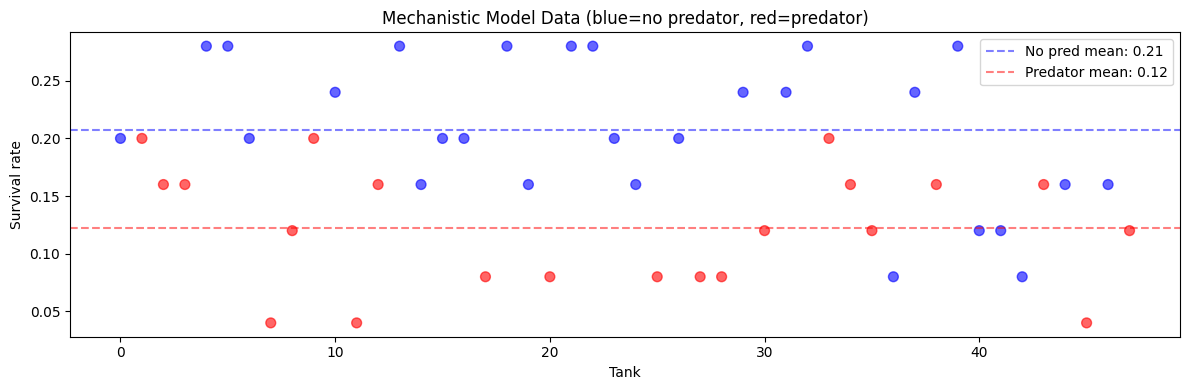

In [6]:
# Visualize the data
fig, ax = plt.subplots(figsize=(12, 4))

observed_p = survived / density
colors = ['blue' if p == 0 else 'red' for p in predator]

ax.scatter(range(n_tanks), observed_p, c=colors, alpha=0.6, s=50)
ax.axhline(y=np.mean(observed_p[predator==0]), color='blue', linestyle='--', 
           alpha=0.5, label=f'No pred mean: {np.mean(observed_p[predator==0]):.2f}')
ax.axhline(y=np.mean(observed_p[predator==1]), color='red', linestyle='--', 
           alpha=0.5, label=f'Predator mean: {np.mean(observed_p[predator==1]):.2f}')
ax.set_xlabel('Tank')
ax.set_ylabel('Survival rate')
ax.set_title('Mechanistic Model Data (blue=no predator, red=predator)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Train Predator-Conditioned NLE

Since predator presence affects survival dynamics, we train a single NLE conditioned on 
**both theta and predator status**: $p(x \mid \theta, \text{predator})$.

This approach (similar to Tutorial 17's density conditioning):
- Creates a smoother likelihood surface
- Uses a single NLE for all tanks
- Enables efficient vectorized evaluation

In [7]:
def simulator_with_predator(theta_predator: torch.Tensor) -> torch.Tensor:
    """Wrapper that takes combined (theta, predator) input."""
    theta = theta_predator[:, 0:1]
    pred_flag = theta_predator[:, 1:2]
    
    batch_size = theta.shape[0]
    results = torch.zeros(batch_size, 1)
    
    # Split by predator status for simulation
    pred_mask = pred_flag.squeeze() > 0.5
    no_pred_mask = ~pred_mask
    
    if pred_mask.any():
        results[pred_mask] = mechanistic_tadpole_simulator(
            theta[pred_mask], density=density, predator=True
        )
    if no_pred_mask.any():
        results[no_pred_mask] = mechanistic_tadpole_simulator(
            theta[no_pred_mask], density=density, predator=False
        )
    
    return results

# Prior for (theta, predator)
# θ in [2.5, 5.0] covers daily survival from ~92% to ~99%
# This gives 30-day survival from ~8% to ~74%
prior = BoxUniform(
    low=torch.tensor([2.5, 0.0]),
    high=torch.tensor([5.0, 1.0]),
)

n_sims = 100000

# Train predator-conditioned NLE
theta_train = torch.rand(n_sims, 1) * 2.5 + 2.5  # [2.5, 5.0]
predator_train = torch.randint(0, 2, (n_sims, 1)).float()  # 0 or 1
theta_predator_train = torch.cat([theta_train, predator_train], dim=1)

x_train = simulator_with_predator(theta_predator_train)

inference = NLE(prior=prior, density_estimator="maf")
inference.append_simulations(theta_predator_train, x_train)
likelihood_nn = inference.train(training_batch_size=256, max_num_epochs=100)

 Neural network successfully converged after 81 epochs.

## 4. SBI-PyMC Hierarchical Inference

Now we build a PyMC hierarchical model using the neural likelihood.
This is **impossible with standard PyMC** because there's no closed-form likelihood!

We pass both the inferred θ and fixed predator status to the NLE.

In [8]:
import pytensor.tensor as pt

# Prepare observations: shape (num_trials=1, num_subjects=n_tanks, event_dim=1)
x_observed = survived.reshape(1, n_tanks, 1).astype(np.float32)

# Fixed predator status as constant tensor: shape (n_tanks, 1)
predator_pt = pt.as_tensor_variable(predator.astype(np.float32).reshape(-1, 1))

In [9]:
coords = {"tank": np.arange(n_tanks)}

with pm.Model(coords=coords) as pymc_model:
    # Hyperpriors - adjusted for daily survival scale
    # α_bar ~ Normal(3.8, 0.5) centers around ~97.8% daily survival
    alpha_bar = pm.Normal("alpha_bar", mu=3.8, sigma=0.5)
    # HalfNormal for population std
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    
    # Predator effect (on daily survival logit scale)
    beta_pred = pm.Normal("beta_pred", mu=0, sigma=0.5)
    
    # Tank-level intercepts (non-centered parameterization)
    z = pm.Normal("z", mu=0, sigma=1, dims="tank")
    alpha = pm.Deterministic("alpha", alpha_bar + z * sigma, dims="tank")
    
    # Compute logit_p for each tank
    logit_p = alpha + beta_pred * predator
    
    # Create conditioning tensor: [theta, predator] for each tank
    theta_col = logit_p.dimshuffle(0, 'x')  # (n_tanks, 1)
    theta_predator = pt.concatenate([theta_col, predator_pt], axis=1)  # (n_tanks, 2)
    
    # Single VECTORIZED NLE call for all 48 tanks
    neural_likelihood_to_pymc(
        likelihood_nn=likelihood_nn,
        theta=theta_predator,  # 2D: [theta, predator]
        observed=x_observed,
        name="x",
        num_trials=1,
        num_subjects=n_tanks,
    )

In [10]:
with pymc_model:
    trace = pm.sample(
        draws=2000,
        tune=2000,  # More tuning for adaptation
        chains=4,
        cores=1,
        random_seed=42,
        target_accept=0.95,  # Higher target_accept reduces divergences
        progressbar=True,
    )

# Check for divergences
n_divergences = trace.sample_stats.diverging.sum().item()
print(f"\nDivergences: {n_divergences}")
print("\nPosterior Summary:")
display(az.summary(trace, var_names=["alpha_bar", "sigma", "beta_pred"]))

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha_bar, sigma, beta_pred, z]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 494 seconds.



Divergences: 0

Posterior Summary:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_bar,3.928,0.137,3.681,4.192,0.002,0.002,5832.0,4495.0,1.0
sigma,0.260,0.161,0.000,0.524,0.003,0.002,2070.0,3022.0,1.0
beta_pred,-0.511,0.184,-0.861,-0.172,0.002,0.002,5921.0,5152.0,1.0


## 5. MCMC Diagnostics

Before interpreting results, we check for sampling issues:
- **Divergences**: Indicate regions where the sampler struggled
- **Energy**: BFMI < 0.3 suggests poor exploration
- **R-hat**: Should be < 1.01 for convergence
- **ESS**: Effective sample size (higher is better)

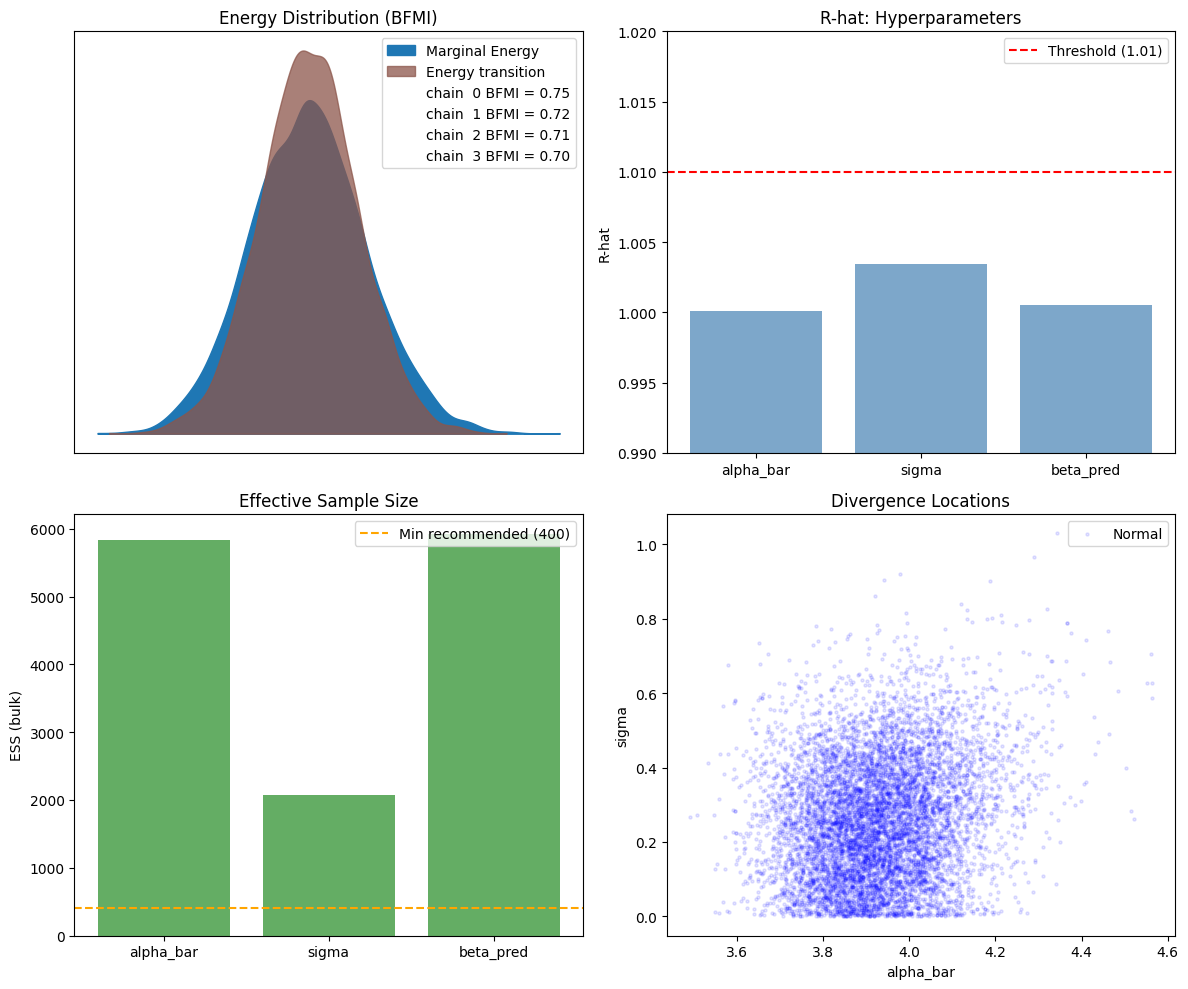

BFMI per chain: [0.74669632 0.72391329 0.70950048 0.70330929]
All BFMI > 0.3: True


In [11]:
# MCMC diagnostics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Energy plot (BFMI diagnostic)
az.plot_energy(trace, ax=axes[0, 0])
axes[0, 0].set_title("Energy Distribution (BFMI)")

# 2. R-hat for all parameters
rhat_vals = az.rhat(trace)
rhat_alpha = rhat_vals["alpha"].values
rhat_z = rhat_vals["z"].values
rhat_hyper = [rhat_vals["alpha_bar"].item(), rhat_vals["sigma"].item(), rhat_vals["beta_pred"].item()]

axes[0, 1].bar(["alpha_bar", "sigma", "beta_pred"], rhat_hyper, color='steelblue', alpha=0.7)
axes[0, 1].axhline(1.01, color='red', linestyle='--', label='Threshold (1.01)')
axes[0, 1].set_ylabel("R-hat")
axes[0, 1].set_title("R-hat: Hyperparameters")
axes[0, 1].legend()
axes[0, 1].set_ylim(0.99, 1.02)

# 3. ESS for hyperparameters
ess_vals = az.ess(trace)
ess_hyper = [ess_vals["alpha_bar"].item(), ess_vals["sigma"].item(), ess_vals["beta_pred"].item()]
axes[1, 0].bar(["alpha_bar", "sigma", "beta_pred"], ess_hyper, color='forestgreen', alpha=0.7)
axes[1, 0].axhline(400, color='orange', linestyle='--', label='Min recommended (400)')
axes[1, 0].set_ylabel("ESS (bulk)")
axes[1, 0].set_title("Effective Sample Size")
axes[1, 0].legend()

# 4. Divergence locations in sigma-alpha_bar space
divergent = trace.sample_stats.diverging.values.flatten()
alpha_bar_samples = trace.posterior["alpha_bar"].values.flatten()
sigma_samples = trace.posterior["sigma"].values.flatten()

axes[1, 1].scatter(alpha_bar_samples[~divergent], sigma_samples[~divergent], 
                   alpha=0.1, s=5, c='blue', label='Normal')
if divergent.any():
    axes[1, 1].scatter(alpha_bar_samples[divergent], sigma_samples[divergent], 
                       c='red', s=20, marker='x', label=f'Divergent ({divergent.sum()})')
axes[1, 1].set_xlabel("alpha_bar")
axes[1, 1].set_ylabel("sigma")
axes[1, 1].set_title("Divergence Locations")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print summary
bfmi = az.bfmi(trace)
print(f"BFMI per chain: {bfmi}")
print(f"All BFMI > 0.3: {all(bfmi > 0.3)}")

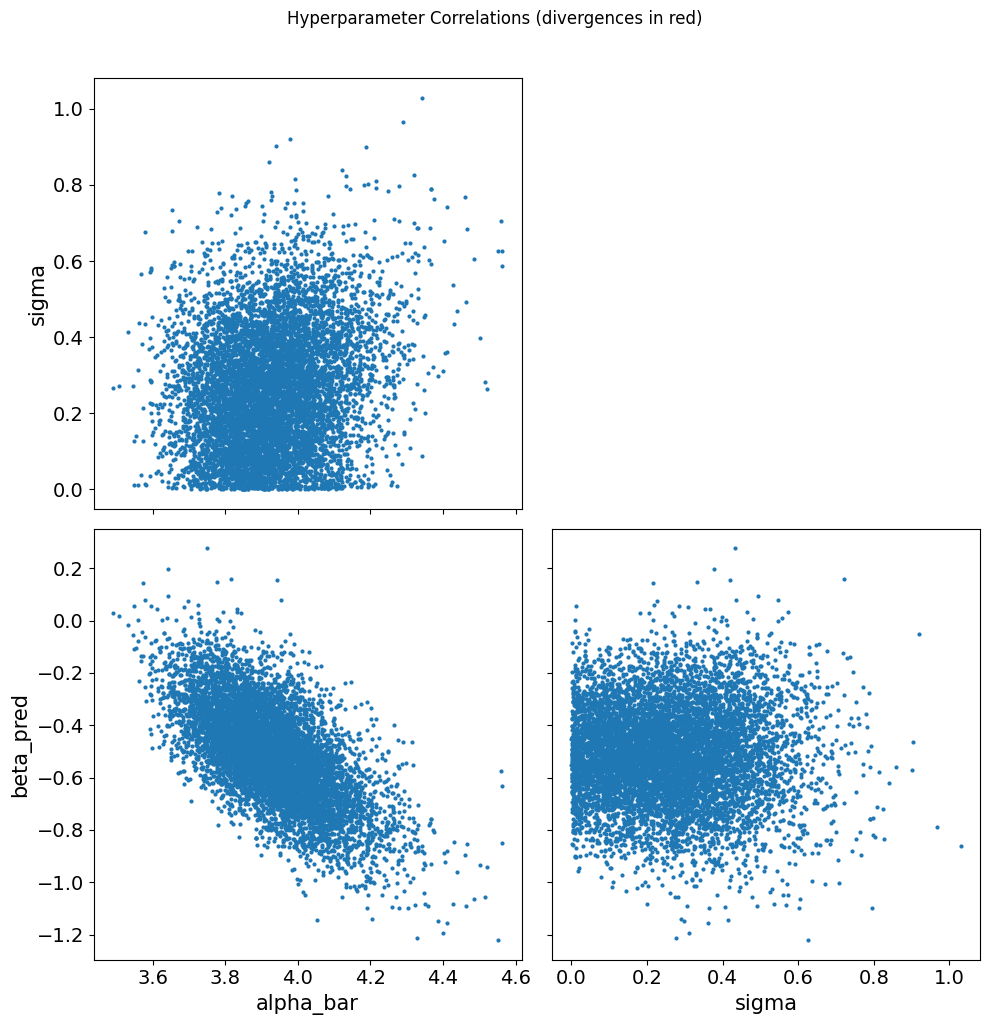

In [12]:
# Pair plot for hyperparameters with divergences highlighted
az.plot_pair(
    trace,
    var_names=["alpha_bar", "sigma", "beta_pred"],
    kind="scatter",
    divergences=True,
    figsize=(10, 10),
)
plt.suptitle("Hyperparameter Correlations (divergences in red)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Results: Posterior Recovery

Let's check if the posteriors recover the true parameter values.

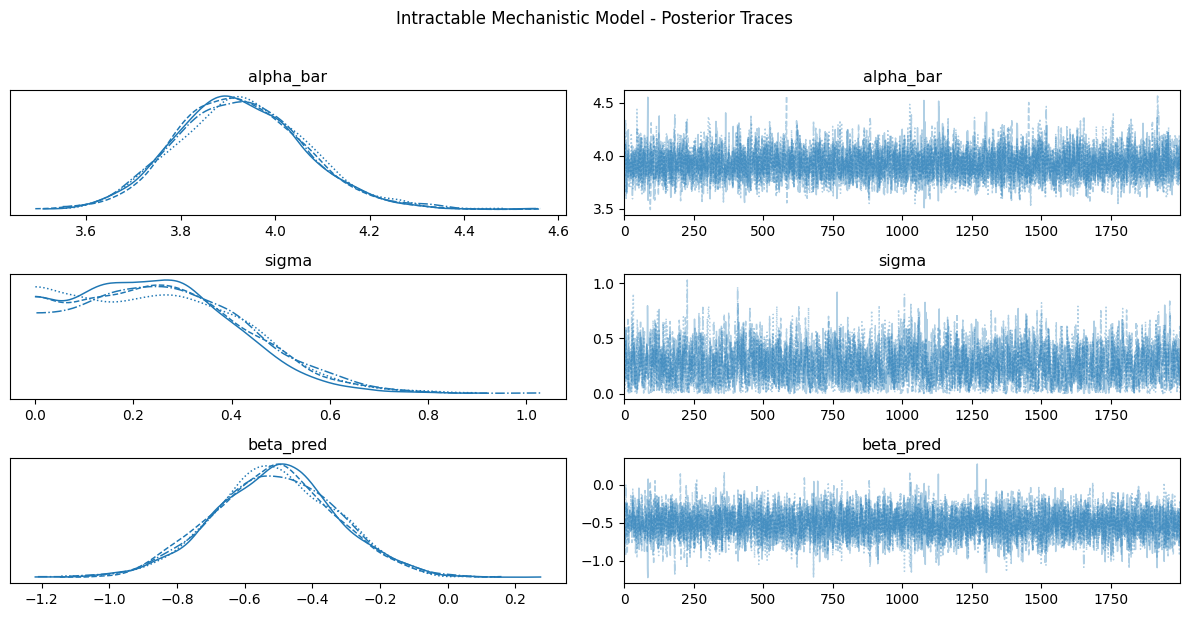

In [13]:
# Trace plots
az.plot_trace(trace, var_names=["alpha_bar", "sigma", "beta_pred"])
plt.suptitle("Intractable Mechanistic Model - Posterior Traces", y=1.02)
plt.tight_layout()
plt.show()

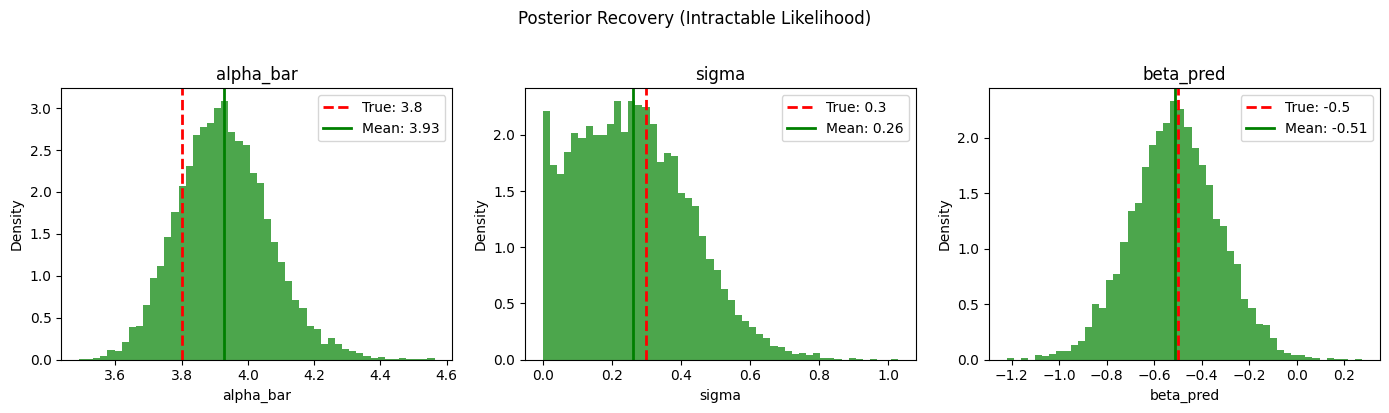

In [14]:
# Compare with true values
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vars_to_plot = ["alpha_bar", "sigma", "beta_pred"]
true_vals = [TRUE_ALPHA_BAR, TRUE_SIGMA, TRUE_BETA_PRED]

for ax, var, true_val in zip(axes, vars_to_plot, true_vals):
    samples = trace.posterior[var].values.flatten()
    ax.hist(samples, bins=50, alpha=0.7, density=True, color='green')
    ax.axvline(x=true_val, color='red', linestyle='--', linewidth=2, label=f'True: {true_val}')
    ax.axvline(x=samples.mean(), color='green', linestyle='-', linewidth=2, 
               label=f'Mean: {samples.mean():.2f}')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.set_title(f'{var}')
    ax.legend()

plt.suptitle('Posterior Recovery (Intractable Likelihood)', y=1.02)
plt.tight_layout()
plt.show()

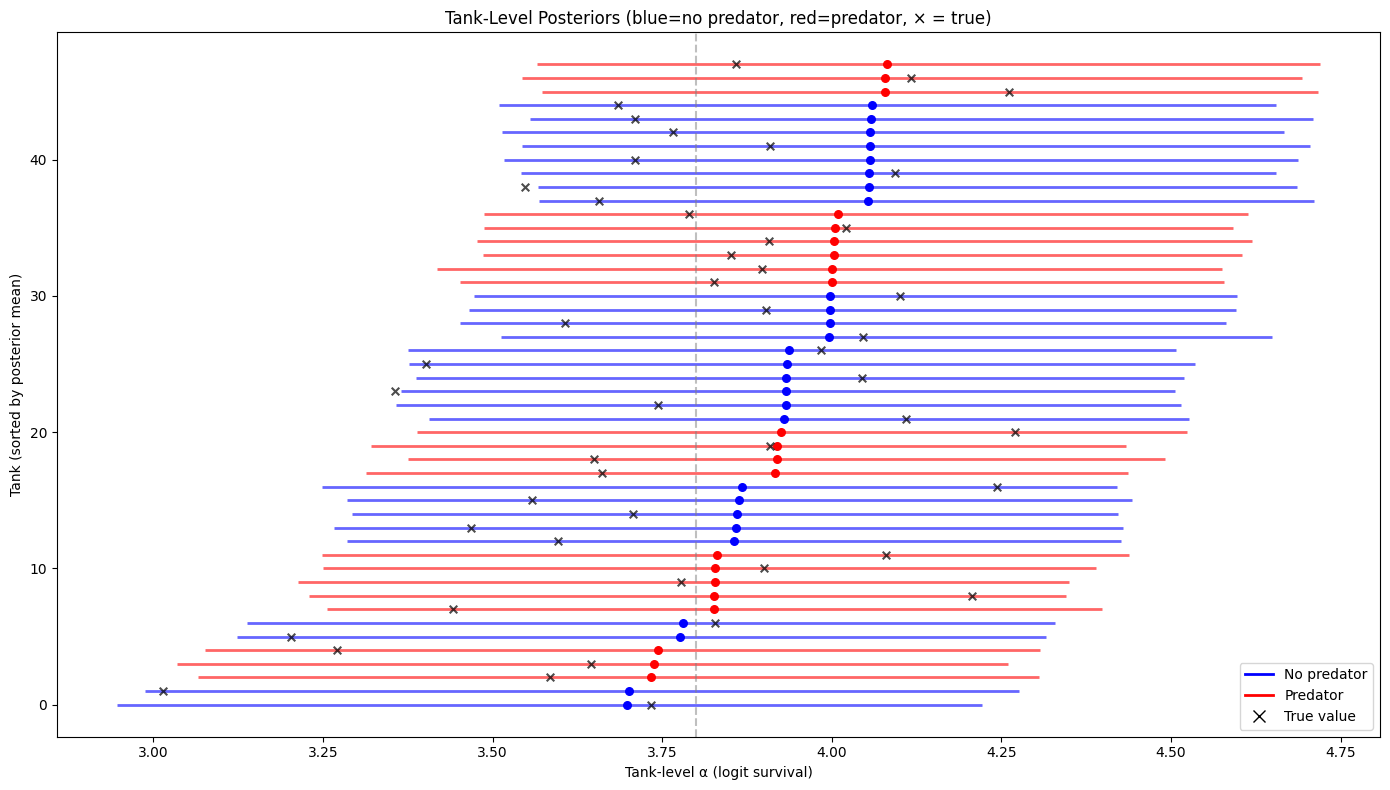

Tank-level coverage (94% HDI contains true α): 95.8%


In [15]:
# Tank-level alpha posteriors (forest plot)
fig, ax = plt.subplots(figsize=(14, 8))

alpha_posterior = trace.posterior["alpha"].values  # (chains, draws, tanks)
alpha_mean = alpha_posterior.mean(axis=(0, 1))
alpha_hdi = az.hdi(trace, var_names=["alpha"])["alpha"].values  # (tanks, 2)

# Sort tanks by posterior mean for cleaner visualization
sort_idx = np.argsort(alpha_mean)

y_positions = np.arange(n_tanks)
colors = ['red' if predator[i] else 'blue' for i in sort_idx]

# Plot HDI intervals and means
for y, idx in enumerate(sort_idx):
    ax.hlines(y, alpha_hdi[idx, 0], alpha_hdi[idx, 1], colors=colors[y], alpha=0.6, linewidth=2)
    ax.scatter(alpha_mean[idx], y, c=colors[y], s=30, zorder=5)
    # True value
    ax.scatter(true_alpha[idx], y, c='black', marker='x', s=30, zorder=6, alpha=0.7)

ax.axvline(TRUE_ALPHA_BAR, color='gray', linestyle='--', alpha=0.5, label=f'True ᾱ = {TRUE_ALPHA_BAR}')
ax.set_xlabel('Tank-level α (logit survival)')
ax.set_ylabel('Tank (sorted by posterior mean)')
ax.set_title('Tank-Level Posteriors (blue=no predator, red=predator, × = true)')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='No predator'),
    Line2D([0], [0], color='red', lw=2, label='Predator'),
    Line2D([0], [0], marker='x', color='black', linestyle='None', markersize=8, label='True value'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Check coverage: what fraction of true alphas fall within 94% HDI?
in_hdi = (true_alpha >= alpha_hdi[:, 0]) & (true_alpha <= alpha_hdi[:, 1])
print(f"Tank-level coverage (94% HDI contains true α): {in_hdi.mean():.1%}")

## 7. Posterior Predictive Check

Let's verify that samples from the posterior, when run through the simulator,
produce data similar to our observations.

In [16]:
# Posterior predictive simulations
n_ppc = 100

alpha_bar_samples = trace.posterior["alpha_bar"].values.flatten()[:n_ppc]
sigma_samples = trace.posterior["sigma"].values.flatten()[:n_ppc]
beta_pred_samples = trace.posterior["beta_pred"].values.flatten()[:n_ppc]

ppc_survived = np.zeros((n_ppc, n_tanks))

for j in range(n_ppc):
    alpha_j = np.random.normal(alpha_bar_samples[j], sigma_samples[j], size=n_tanks)
    logit_p_j = alpha_j + beta_pred_samples[j] * predator
    
    for i in range(n_tanks):
        theta_ij = torch.tensor([[logit_p_j[i]]])
        ppc_survived[j, i] = mechanistic_tadpole_simulator(
            theta_ij, density=density, predator=bool(predator[i])
        ).item()

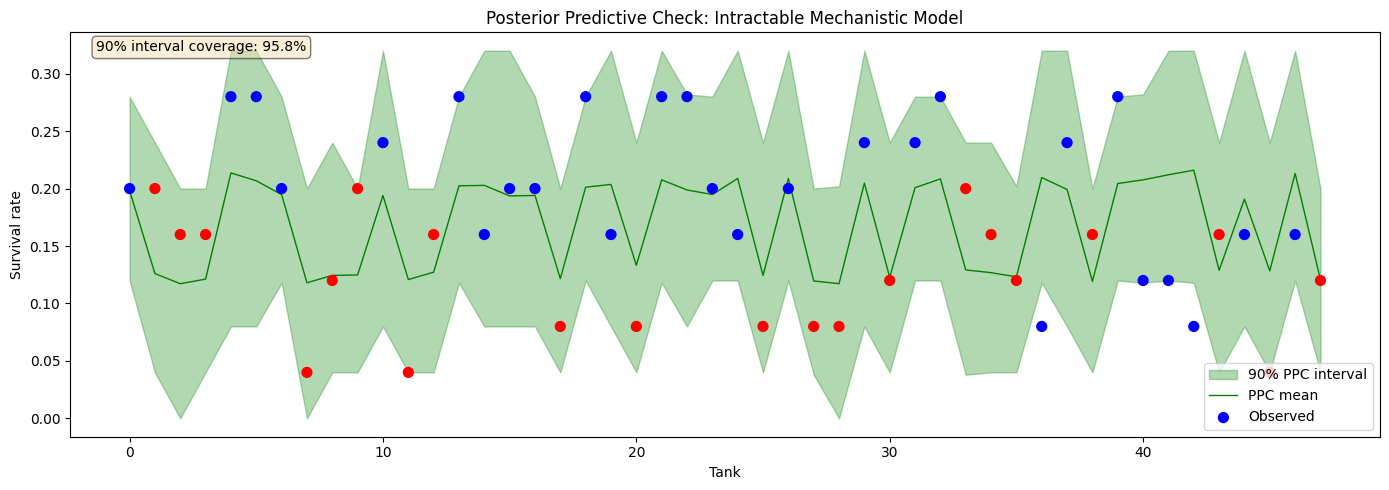

In [17]:
# Plot posterior predictive check
fig, ax = plt.subplots(figsize=(14, 5))

# Posterior predictive intervals
ppc_mean = ppc_survived.mean(axis=0) / density
ppc_low = np.percentile(ppc_survived, 5, axis=0) / density
ppc_high = np.percentile(ppc_survived, 95, axis=0) / density

# Plot intervals
ax.fill_between(range(n_tanks), ppc_low, ppc_high, alpha=0.3, color='green', label='90% PPC interval')
ax.plot(range(n_tanks), ppc_mean, 'g-', linewidth=1, label='PPC mean')

# Observed data
obs_rate = survived / density
ax.scatter(range(n_tanks), obs_rate, 
           c=['blue' if p == 0 else 'red' for p in predator],
           s=50, zorder=5, label='Observed')

ax.set_xlabel('Tank')
ax.set_ylabel('Survival rate')
ax.set_title('Posterior Predictive Check: Intractable Mechanistic Model')
ax.legend(loc='lower right')

# Calculate coverage
in_interval = (obs_rate >= ppc_low) & (obs_rate <= ppc_high)
coverage = in_interval.mean()
ax.text(0.02, 0.98, f'90% interval coverage: {coverage:.1%}', 
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 8. Scientific Interpretation

Having validated our inference, we now interpret the results ecologically. This section draws on
the multilevel modeling insights from [McElreath's Statistical Rethinking](https://xcelab.net/rm/statistical-rethinking/)
and demonstrates what we gain scientifically by combining mechanistic simulators with hierarchical Bayesian inference.

### The Value of Partial Pooling

The hierarchical model performs **partial pooling** - each tank's estimate is informed by both
its own data and the population-level parameters learned from all tanks. This is a principled
middle ground between:

- **Complete pooling**: Assume all tanks are identical (underfits - ignores real variation)
- **No pooling**: Treat each tank independently (overfits - ignores shared biology)
- **Partial pooling**: Tanks share information through the population distribution (optimal trade-off)

The key insight, traced back to [Stein (1956)](https://en.wikipedia.org/wiki/Stein%27s_example),
is that pooling information across groups *always* improves estimation on average, even when
groups are genuinely different.

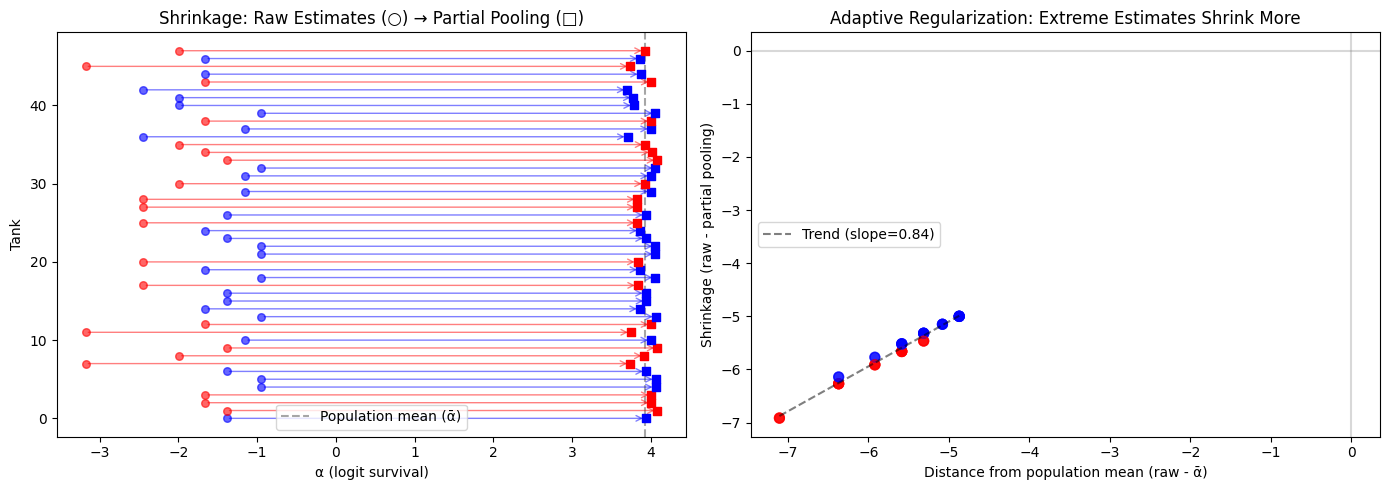

Average absolute shrinkage: 5.63 (logit scale)
Shrinkage correlation with extremity: 0.99


In [18]:
# Visualize shrinkage: compare raw estimates vs partial pooling estimates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw "no-pooling" estimates (just observed proportion, logit-transformed)
# Avoid log(0) by clipping
obs_p_clipped = np.clip(survived / density, 0.01, 0.99)
raw_logit = np.log(obs_p_clipped / (1 - obs_p_clipped))

# Partial pooling estimates from the model
partial_pool = alpha_mean  # posterior means

# Population mean
pop_mean = trace.posterior["alpha_bar"].values.mean()

# Plot 1: Shrinkage toward the mean
ax = axes[0]
for i in range(n_tanks):
    color = 'red' if predator[i] else 'blue'
    # Arrow from raw to shrunk estimate
    ax.annotate('', xy=(partial_pool[i], i), xytext=(raw_logit[i], i),
                arrowprops=dict(arrowstyle='->', color=color, alpha=0.5, lw=1))
    ax.scatter(raw_logit[i], i, c=color, marker='o', s=30, alpha=0.6, zorder=5)
    ax.scatter(partial_pool[i], i, c=color, marker='s', s=30, zorder=5)

ax.axvline(pop_mean, color='gray', linestyle='--', alpha=0.7, label=f'Population mean (ᾱ)')
ax.set_xlabel('α (logit survival)')
ax.set_ylabel('Tank')
ax.set_title('Shrinkage: Raw Estimates (○) → Partial Pooling (□)')
ax.legend()

# Plot 2: Shrinkage magnitude vs distance from mean
ax = axes[1]
shrinkage = raw_logit - partial_pool  # positive = shrunk toward mean
distance_from_mean = raw_logit - pop_mean

colors = ['red' if p else 'blue' for p in predator]
ax.scatter(distance_from_mean, shrinkage, c=colors, alpha=0.6, s=50)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(0, color='gray', linestyle='-', alpha=0.3)

# Add trend line
z = np.polyfit(distance_from_mean, shrinkage, 1)
x_line = np.linspace(distance_from_mean.min(), distance_from_mean.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'k--', alpha=0.5, label=f'Trend (slope={z[0]:.2f})')

ax.set_xlabel('Distance from population mean (raw - ᾱ)')
ax.set_ylabel('Shrinkage (raw - partial pooling)')
ax.set_title('Adaptive Regularization: Extreme Estimates Shrink More')
ax.legend()

plt.tight_layout()
plt.show()

# Quantify shrinkage
print(f"Average absolute shrinkage: {np.abs(shrinkage).mean():.2f} (logit scale)")
print(f"Shrinkage correlation with extremity: {np.corrcoef(np.abs(distance_from_mean), np.abs(shrinkage))[0,1]:.2f}")

### Interpreting the Hyperparameters

The hierarchical model estimates three key population-level parameters. Let's interpret them ecologically:

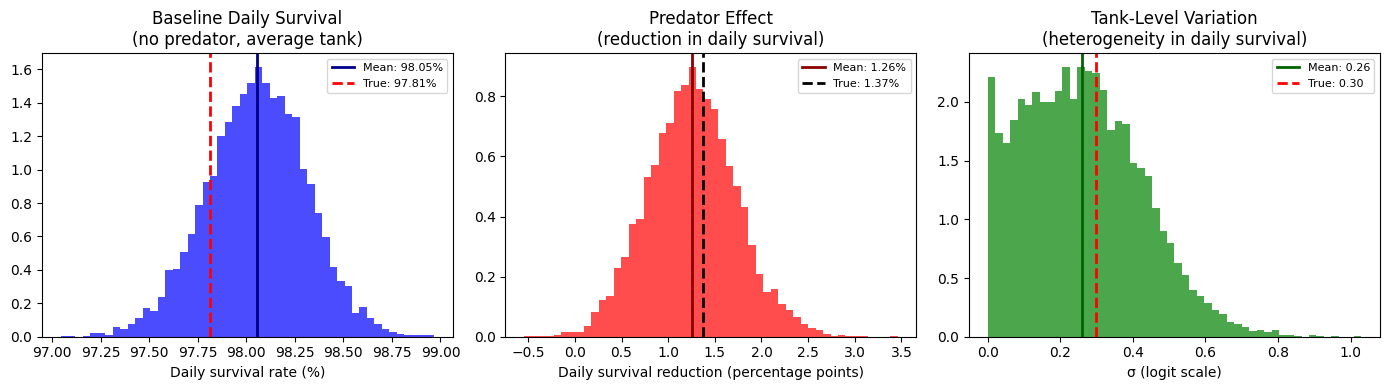

ECOLOGICAL INTERPRETATION (Daily Survival Scale)

1. BASELINE DAILY SURVIVAL (no predator, average tank):
   Mean: 98.05% per day
   95% CI: 97.54% - 98.54%
   → Implies ~55.6% 30-day survival (uncrowded)

2. PREDATOR EFFECT:
   β_pred mean: -0.511
   95% CI: -0.866 to -0.149
   Daily survival reduction: 1.26 percentage points
   Probability that predators reduce survival: 99.6%

3. TANK-LEVEL VARIATION:
   σ mean: 0.260
   95% CI: 0.010 to 0.603
   → Variation in daily survival rates across tanks


In [19]:
# Extract posterior summaries
alpha_bar_post = trace.posterior["alpha_bar"].values.flatten()
sigma_post = trace.posterior["sigma"].values.flatten()
beta_pred_post = trace.posterior["beta_pred"].values.flatten()

# Convert to probability scale for interpretation
# θ represents DAILY survival (logit scale)
daily_survival_no_pred = expit(alpha_bar_post)
daily_survival_pred = expit(alpha_bar_post + beta_pred_post)

# Approximate 30-day survival (without crowding effects)
survival_30d_no_pred = daily_survival_no_pred ** 30
survival_30d_pred = daily_survival_pred ** 30

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Daily survival (no predator)
ax = axes[0]
ax.hist(daily_survival_no_pred * 100, bins=50, alpha=0.7, color='blue', density=True)
ax.axvline(np.mean(daily_survival_no_pred) * 100, color='darkblue', linestyle='-', lw=2,
           label=f'Mean: {np.mean(daily_survival_no_pred)*100:.2f}%')
ax.axvline(expit(TRUE_ALPHA_BAR) * 100, color='red', linestyle='--', lw=2,
           label=f'True: {expit(TRUE_ALPHA_BAR)*100:.2f}%')
ax.set_xlabel('Daily survival rate (%)')
ax.set_title('Baseline Daily Survival\n(no predator, average tank)')
ax.legend(fontsize=8)

# 2. Predator effect on daily survival
ax = axes[1]
daily_reduction = (daily_survival_no_pred - daily_survival_pred) * 100
ax.hist(daily_reduction, bins=50, alpha=0.7, color='red', density=True)
ax.axvline(np.mean(daily_reduction), color='darkred', linestyle='-', lw=2,
           label=f'Mean: {np.mean(daily_reduction):.2f}%')
true_daily_reduction = (expit(TRUE_ALPHA_BAR) - expit(TRUE_ALPHA_BAR + TRUE_BETA_PRED)) * 100
ax.axvline(true_daily_reduction, color='black', linestyle='--', lw=2,
           label=f'True: {true_daily_reduction:.2f}%')
ax.set_xlabel('Daily survival reduction (percentage points)')
ax.set_title('Predator Effect\n(reduction in daily survival)')
ax.legend(fontsize=8)

# 3. Tank-level variation (sigma)
ax = axes[2]
ax.hist(sigma_post, bins=50, alpha=0.7, color='green', density=True)
ax.axvline(np.mean(sigma_post), color='darkgreen', linestyle='-', lw=2,
           label=f'Mean: {np.mean(sigma_post):.2f}')
ax.axvline(TRUE_SIGMA, color='red', linestyle='--', lw=2,
           label=f'True: {TRUE_SIGMA:.2f}')
ax.set_xlabel('σ (logit scale)')
ax.set_title('Tank-Level Variation\n(heterogeneity in daily survival)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print ecological interpretation
print("=" * 70)
print("ECOLOGICAL INTERPRETATION (Daily Survival Scale)")
print("=" * 70)
print(f"\n1. BASELINE DAILY SURVIVAL (no predator, average tank):")
print(f"   Mean: {np.mean(daily_survival_no_pred)*100:.2f}% per day")
print(f"   95% CI: {np.percentile(daily_survival_no_pred, 2.5)*100:.2f}% - {np.percentile(daily_survival_no_pred, 97.5)*100:.2f}%")
print(f"   → Implies ~{np.mean(survival_30d_no_pred)*100:.1f}% 30-day survival (uncrowded)")

print(f"\n2. PREDATOR EFFECT:")
print(f"   β_pred mean: {np.mean(beta_pred_post):.3f}")
print(f"   95% CI: {np.percentile(beta_pred_post, 2.5):.3f} to {np.percentile(beta_pred_post, 97.5):.3f}")
print(f"   Daily survival reduction: {np.mean(daily_reduction):.2f} percentage points")
prob_negative = (beta_pred_post < 0).mean()
print(f"   Probability that predators reduce survival: {prob_negative*100:.1f}%")

print(f"\n3. TANK-LEVEL VARIATION:")
print(f"   σ mean: {np.mean(sigma_post):.3f}")
print(f"   95% CI: {np.percentile(sigma_post, 2.5):.3f} to {np.percentile(sigma_post, 97.5):.3f}")
print(f"   → Variation in daily survival rates across tanks")

### Understanding the Mechanistic Dynamics

The key scientific advantage of our mechanistic simulator is that it captures **density-dependent processes**
that a simple Binomial model cannot represent. Let's visualize what's happening inside the simulator.

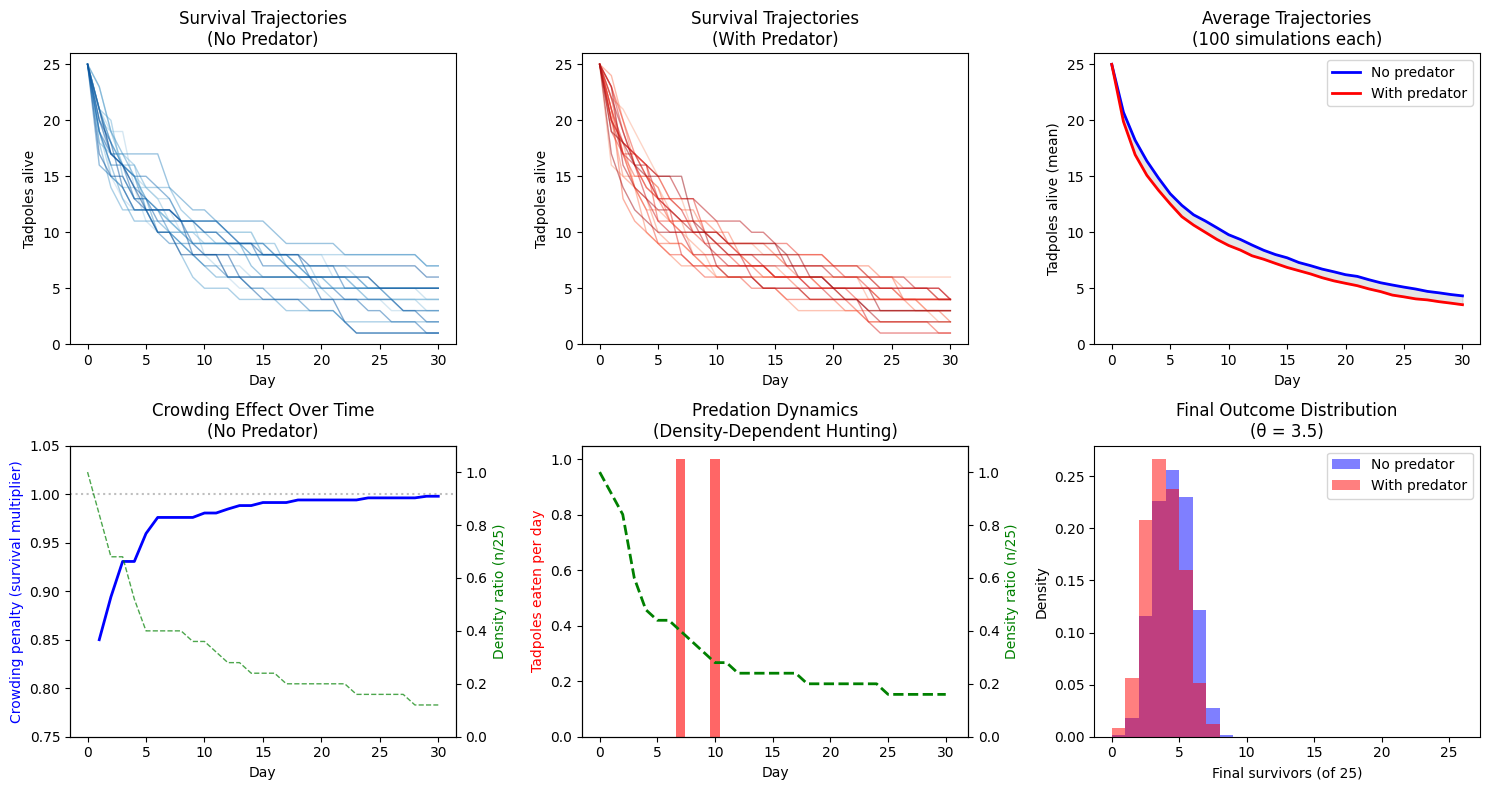

Parameter interpretation (θ = 3.5):
  Base daily survival (sigmoid(θ)): 97.1%
  Expected 30-day survival (uncrowded Binomial): 41.0%
  Mean final survivors (no predator): 4.0 / 25 = 16.2%
  Mean final survivors (with predator): 3.4 / 25 = 13.7%


In [20]:
# Modified simulator that tracks daily trajectories
def mechanistic_simulator_with_trajectory(theta, density=25, predator=False, n_days=30):
    """
    Returns both final count and daily trajectory.
    
    Args:
        theta: Baseline daily survival (logit scale) - same interpretation as main simulator
    """
    n_alive = float(density)
    initial_density = float(density)
    trajectory = [n_alive]
    crowding_history = []
    predation_history = []
    
    # θ represents baseline daily survival (logit scale) BEFORE crowding
    base_daily_survival = 1 / (1 + np.exp(-theta))  # sigmoid
    
    for day in range(n_days):
        if n_alive == 0:
            trajectory.append(0)
            crowding_history.append(1.0)
            predation_history.append(0)
            continue
            
        density_ratio = n_alive / initial_density
        
        # Crowding effect (same as main simulator)
        crowding_penalty = 1.0 - 0.15 * (density_ratio ** 2)
        crowding_penalty = np.clip(crowding_penalty, 0.8, 1.0)
        crowding_history.append(crowding_penalty)
        
        # Predator attacks
        n_eaten = 0
        if predator:
            attack_rate = 0.03 * density_ratio
            attack_rate = np.clip(attack_rate, 0, 0.05)
            n_eaten = np.random.binomial(int(n_alive), attack_rate)
            n_alive = max(0, n_alive - n_eaten)
        predation_history.append(n_eaten)
        
        # Realized daily survival
        daily_survival = base_daily_survival * crowding_penalty
        daily_survival = np.clip(daily_survival, 0.5, 0.999)
        
        survivors = np.random.binomial(int(n_alive), daily_survival)
        n_alive = survivors
        trajectory.append(n_alive)
    
    return trajectory, crowding_history, predation_history

# Simulate trajectories for different scenarios
np.random.seed(42)

# With the new parameterization, θ is daily survival (logit scale)
# θ = 2 → sigmoid(2) ≈ 0.88 daily survival → ~0.88^30 ≈ 2% 30-day survival (very low!)
# θ = 3 → sigmoid(3) ≈ 0.95 daily survival → ~0.95^30 ≈ 21% 30-day survival
# θ = 4 → sigmoid(4) ≈ 0.98 daily survival → ~0.98^30 ≈ 55% 30-day survival
theta_example = 3.5  # ~0.97 daily survival, ~40% 30-day survival in uncrowded Binomial

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Run multiple simulations to show stochasticity
n_trajectories = 20
colors_no_pred = plt.cm.Blues(np.linspace(0.3, 0.9, n_trajectories))
colors_pred = plt.cm.Reds(np.linspace(0.3, 0.9, n_trajectories))

# Panel 1: Survival trajectories without predator
ax = axes[0, 0]
for i in range(n_trajectories):
    traj, _, _ = mechanistic_simulator_with_trajectory(theta_example, predator=False)
    ax.plot(traj, color=colors_no_pred[i], alpha=0.5, lw=1)
ax.set_xlabel('Day')
ax.set_ylabel('Tadpoles alive')
ax.set_title('Survival Trajectories\n(No Predator)')
ax.set_ylim(0, 26)

# Panel 2: Survival trajectories with predator
ax = axes[0, 1]
for i in range(n_trajectories):
    traj, _, _ = mechanistic_simulator_with_trajectory(theta_example, predator=True)
    ax.plot(traj, color=colors_pred[i], alpha=0.5, lw=1)
ax.set_xlabel('Day')
ax.set_ylabel('Tadpoles alive')
ax.set_title('Survival Trajectories\n(With Predator)')
ax.set_ylim(0, 26)

# Panel 3: Compare average trajectories
ax = axes[0, 2]
avg_no_pred = np.mean([mechanistic_simulator_with_trajectory(theta_example, predator=False)[0] 
                        for _ in range(100)], axis=0)
avg_pred = np.mean([mechanistic_simulator_with_trajectory(theta_example, predator=True)[0] 
                    for _ in range(100)], axis=0)
ax.plot(avg_no_pred, 'b-', lw=2, label='No predator')
ax.plot(avg_pred, 'r-', lw=2, label='With predator')
ax.fill_between(range(31), avg_no_pred, avg_pred, alpha=0.2, color='gray')
ax.set_xlabel('Day')
ax.set_ylabel('Tadpoles alive (mean)')
ax.set_title('Average Trajectories\n(100 simulations each)')
ax.legend()
ax.set_ylim(0, 26)

# Panel 4: Crowding penalty over time
ax = axes[1, 0]
# Single trajectory to show crowding dynamics
traj, crowding, _ = mechanistic_simulator_with_trajectory(theta_example, predator=False)
ax.plot(range(1, len(crowding)+1), crowding, 'b-', lw=2, label='Crowding penalty')
ax2 = ax.twinx()
ax2.plot(range(len(traj)), np.array(traj)/25, 'g--', lw=1, alpha=0.7, label='Density ratio')
ax.set_xlabel('Day')
ax.set_ylabel('Crowding penalty (survival multiplier)', color='blue')
ax2.set_ylabel('Density ratio (n/25)', color='green')
ax.set_title('Crowding Effect Over Time\n(No Predator)')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.set_ylim(0.75, 1.05)
ax2.set_ylim(0, 1.1)

# Panel 5: Predation rate over time (with predator)
ax = axes[1, 1]
traj, crowding, predation = mechanistic_simulator_with_trajectory(theta_example, predator=True)
ax.bar(range(1, len(predation)+1), predation, color='red', alpha=0.6, label='Tadpoles eaten')
ax2 = ax.twinx()
ax2.plot(range(len(traj)), np.array(traj)/25, 'g--', lw=2, label='Density ratio')
ax.set_xlabel('Day')
ax.set_ylabel('Tadpoles eaten per day', color='red')
ax2.set_ylabel('Density ratio (n/25)', color='green')
ax.set_title('Predation Dynamics\n(Density-Dependent Hunting)')
ax2.set_ylim(0, 1.1)

# Panel 6: Final distribution comparison
ax = axes[1, 2]
final_no_pred = [mechanistic_simulator_with_trajectory(theta_example, predator=False)[0][-1] 
                 for _ in range(500)]
final_pred = [mechanistic_simulator_with_trajectory(theta_example, predator=True)[0][-1] 
              for _ in range(500)]
ax.hist(final_no_pred, bins=range(0, 27), alpha=0.5, color='blue', label='No predator', density=True)
ax.hist(final_pred, bins=range(0, 27), alpha=0.5, color='red', label='With predator', density=True)
ax.set_xlabel('Final survivors (of 25)')
ax.set_ylabel('Density')
ax.set_title(f'Final Outcome Distribution\n(θ = {theta_example})')
ax.legend()

plt.tight_layout()
plt.show()

# Print interpretation with correct parameterization
daily_surv = expit(theta_example)
uncrowded_30day = daily_surv ** 30
print(f"Parameter interpretation (θ = {theta_example}):")
print(f"  Base daily survival (sigmoid(θ)): {daily_surv*100:.1f}%")
print(f"  Expected 30-day survival (uncrowded Binomial): {uncrowded_30day*100:.1f}%")
print(f"  Mean final survivors (no predator): {np.mean(final_no_pred):.1f} / 25 = {np.mean(final_no_pred)/25*100:.1f}%")
print(f"  Mean final survivors (with predator): {np.mean(final_pred):.1f} / 25 = {np.mean(final_pred)/25*100:.1f}%")

### Binomial vs Mechanistic: A Fair Comparison

Now that θ represents **baseline daily survival** (logit scale) in both models, we can make
a fair comparison. Both models apply `sigmoid(θ)` as the daily survival probability, but:

- **Daily Binomial**: 30 independent daily survival events, each with probability `sigmoid(θ)`
- **Mechanistic**: Same base rate, but crowding reduces survival when population is high

This isolates the **pure effect of density dependence**.

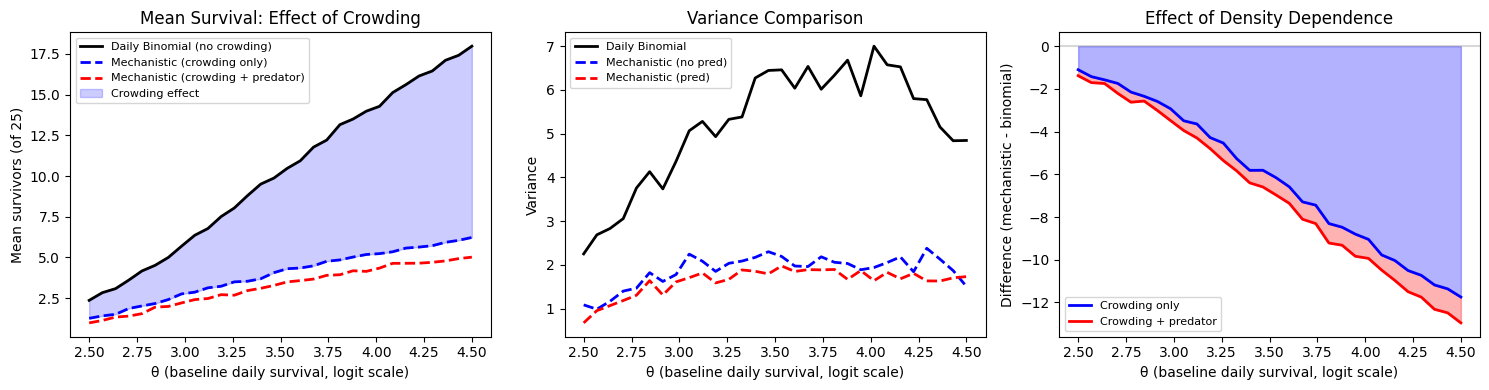

FAIR COMPARISON: EFFECT OF DENSITY DEPENDENCE

At θ = 3.5 (daily survival ≈ 97%):
  Daily Binomial (no crowding): 9.9 survivors
  Mechanistic (crowding only):  4.1 survivors
  Mechanistic (crowding + pred): 3.3 survivors

  Crowding effect: -5.8 fewer survivors
  Predator effect: 0.8 fewer survivors

  Variance ratio (mechanistic/binomial): 0.36
  → Crowding REDUCES variance (self-regulation prevents extreme outcomes)


In [21]:
# Fair comparison: Both models use θ as daily survival (logit scale)
# Daily Binomial: 30 independent days with p = sigmoid(θ)
# Mechanistic: Same but with crowding effect

def daily_binomial_simulator(theta, density=25, n_days=30):
    """Binomial model with 30 independent daily survival events."""
    daily_p = expit(theta)
    n_alive = density
    for day in range(n_days):
        if n_alive == 0:
            break
        n_alive = np.random.binomial(n_alive, daily_p)
    return n_alive

# Compare across theta range
theta_range = np.linspace(2.5, 4.5, 30)  # Range where daily survival is reasonable
n_samples = 300

daily_binom_means = []
daily_binom_stds = []
mechanistic_means_no_pred = []
mechanistic_stds_no_pred = []
mechanistic_means_pred = []
mechanistic_stds_pred = []

for theta in theta_range:
    # Daily Binomial (no crowding)
    binom_samples = [daily_binomial_simulator(theta) for _ in range(n_samples)]
    daily_binom_means.append(np.mean(binom_samples))
    daily_binom_stds.append(np.std(binom_samples))
    
    # Mechanistic (no predator) - has crowding
    mech_samples = [mechanistic_simulator_with_trajectory(theta, predator=False)[0][-1] 
                    for _ in range(n_samples)]
    mechanistic_means_no_pred.append(np.mean(mech_samples))
    mechanistic_stds_no_pred.append(np.std(mech_samples))
    
    # Mechanistic (with predator) - has crowding + predation
    mech_samples_pred = [mechanistic_simulator_with_trajectory(theta, predator=True)[0][-1] 
                         for _ in range(n_samples)]
    mechanistic_means_pred.append(np.mean(mech_samples_pred))
    mechanistic_stds_pred.append(np.std(mech_samples_pred))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Mean survival comparison
ax = axes[0]
ax.plot(theta_range, daily_binom_means, 'k-', lw=2, label='Daily Binomial (no crowding)')
ax.plot(theta_range, mechanistic_means_no_pred, 'b--', lw=2, label='Mechanistic (crowding only)')
ax.plot(theta_range, mechanistic_means_pred, 'r--', lw=2, label='Mechanistic (crowding + predator)')
ax.fill_between(theta_range, daily_binom_means, mechanistic_means_no_pred, alpha=0.2, color='blue',
                label='Crowding effect')
ax.set_xlabel('θ (baseline daily survival, logit scale)')
ax.set_ylabel('Mean survivors (of 25)')
ax.set_title('Mean Survival: Effect of Crowding')
ax.legend(fontsize=8)

# Panel 2: Variance comparison
ax = axes[1]
ax.plot(theta_range, np.array(daily_binom_stds)**2, 'k-', lw=2, label='Daily Binomial')
ax.plot(theta_range, np.array(mechanistic_stds_no_pred)**2, 'b--', lw=2, label='Mechanistic (no pred)')
ax.plot(theta_range, np.array(mechanistic_stds_pred)**2, 'r--', lw=2, label='Mechanistic (pred)')
ax.set_xlabel('θ (baseline daily survival, logit scale)')
ax.set_ylabel('Variance')
ax.set_title('Variance Comparison')
ax.legend(fontsize=8)

# Panel 3: Crowding effect (difference from Binomial)
ax = axes[2]
diff_no_pred = np.array(mechanistic_means_no_pred) - np.array(daily_binom_means)
diff_pred = np.array(mechanistic_means_pred) - np.array(daily_binom_means)
ax.plot(theta_range, diff_no_pred, 'b-', lw=2, label='Crowding only')
ax.plot(theta_range, diff_pred, 'r-', lw=2, label='Crowding + predator')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.fill_between(theta_range, 0, diff_no_pred, alpha=0.3, color='blue')
ax.fill_between(theta_range, diff_no_pred, diff_pred, alpha=0.3, color='red')
ax.set_xlabel('θ (baseline daily survival, logit scale)')
ax.set_ylabel('Difference (mechanistic - binomial)')
ax.set_title('Effect of Density Dependence')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Quantify the effects
print("=" * 70)
print("FAIR COMPARISON: EFFECT OF DENSITY DEPENDENCE")
print("=" * 70)
print(f"\nAt θ = 3.5 (daily survival ≈ {expit(3.5)*100:.0f}%):")
idx = np.argmin(np.abs(theta_range - 3.5))
print(f"  Daily Binomial (no crowding): {daily_binom_means[idx]:.1f} survivors")
print(f"  Mechanistic (crowding only):  {mechanistic_means_no_pred[idx]:.1f} survivors")
print(f"  Mechanistic (crowding + pred): {mechanistic_means_pred[idx]:.1f} survivors")
print(f"\n  Crowding effect: {diff_no_pred[idx]:.1f} fewer survivors")
print(f"  Predator effect: {mechanistic_means_no_pred[idx] - mechanistic_means_pred[idx]:.1f} fewer survivors")

# Variance analysis
var_ratio = np.array(mechanistic_stds_no_pred)**2 / np.array(daily_binom_stds)**2
print(f"\n  Variance ratio (mechanistic/binomial): {var_ratio[idx]:.2f}")
if var_ratio[idx] < 1:
    print(f"  → Crowding REDUCES variance (self-regulation prevents extreme outcomes)")
else:
    print(f"  → Crowding INCREASES variance at this parameter value")

### Ecological Insights from the Mechanistic Model

The comparison above reveals key ecological insights that emerge from density-dependent dynamics.

> **Note:** This simulator is a **pedagogical example** designed to illustrate how SBI enables 
> inference for mechanistic models. The specific functional forms and parameters are illustrative,
> not validated against real tadpole ecology.

#### 1. Negative Density Dependence (Crowding Effect)

The mechanistic model implements *negative density dependence*: survival decreases when population 
density is high. This is a fundamental ecological principle - competition for limited resources
(food, space, oxygen) intensifies as populations grow.

**Mathematical form in our simulator:**
```
crowding_penalty = 1.0 - 0.15 × (density_ratio)²
```

This means:
- At full density (ratio = 1.0): daily survival is reduced by 15%
- At half density (ratio = 0.5): daily survival is reduced by only 3.75%
- At low density (ratio ≈ 0): nearly no crowding effect

#### 2. Self-Regulation Through Mortality

The mechanistic model produces a *negative feedback loop*:
1. High survival → more tadpoles → more crowding
2. More crowding → reduced daily survival → population declines
3. Population decline → less crowding → improved survival for survivors

This creates **self-regulation**: extreme outcomes become less likely because density dependence
dampens fluctuations. Whether this reduces variance depends on the specific parameter regime.

#### 3. Density-Dependent Predation

Predators in our model are more successful when prey is abundant:
```
attack_rate = 0.03 × density_ratio
```

This is ecologically plausible - predators may:
- Encounter prey more frequently when crowded
- Use area-search foraging more effectively at high density

This creates an additional density-dependent mortality source beyond natural crowding.

#### 4. Parameter Interpretation

| Parameter | Daily Binomial | Mechanistic Model |
|-----------|----------------|-------------------|
| θ (alpha) | Base daily survival (logit) | **Same**: base daily survival before crowding |
| Realized survival | `sigmoid(θ)` each day | `sigmoid(θ) × crowding_penalty` each day |
| 30-day outcome | Product of 30 independent days | Product with density-dependent interactions |

In both models, θ represents the same quantity: baseline daily survival on the logit scale.
The difference is that the mechanistic model *modifies* this rate based on current population state.

### What Did We Win Scientifically?

The combination of **mechanistic simulation** with **hierarchical Bayesian inference** provides
unique scientific advantages:

#### 1. Process-Based Understanding

Unlike a simple aggregated Binomial model, our mechanistic simulator captures *how* survival
happens - through daily competition and predation dynamics. The parameter θ has a clear
causal interpretation: it's the **baseline daily survival rate** that would occur without crowding.

| Parameter | Daily Binomial | Mechanistic Model |
|-----------|----------------|-------------------|
| θ (alpha) | Base daily survival (logit) | Same: base daily survival before crowding |
| Crowding effect | None | Reduces realized survival at high density |
| Predator effect | None (would need separate model) | Density-dependent hunting built in |

#### 2. Capturing Ecological Feedbacks

The crowding effect creates **self-regulation** - a negative feedback loop where high survival
leads to crowding, which reduces subsequent survival. This is a fundamental principle in 
population ecology. With SBI, we can now do **Bayesian inference on self-regulating systems**
that have no closed-form likelihood.

#### 3. Model Matters for Inference

The fair comparison above shows that crowding systematically reduces survival compared to
a model without density dependence. If we fit a non-crowding model to data generated with 
crowding, we would get biased parameter estimates. Using the correct mechanistic model
through SBI avoids this misspecification.

#### 4. Inference for Models That Were Previously Inaccessible

Before SBI, researchers faced a difficult choice:
- Use simple tractable models that miss important biology
- Use mechanistic models but rely on ad-hoc fitting methods (least squares, ABC)

The SBI-PyMC bridge enables **principled Bayesian inference** for mechanistic models:
- Full posterior distributions (not just point estimates)
- Proper uncertainty quantification
- Hierarchical structure with partial pooling
- Gradient-based MCMC for efficient sampling

#### 5. Generalization to New Conditions

Because we trained a **condition-aware NLE** (conditioned on predator status), we can:
- Make predictions for new tanks with known predator status
- Ask counterfactual questions: "What if this tank had a predator?"

### Conclusions

1. **Predators reduce tadpole survival** - The β_pred effect captures additional mortality
   from predation, which in our mechanistic model operates through density-dependent hunting.

2. **Crowding creates density-dependent mortality** - The mechanistic model shows that
   survival is self-regulating: crowded tanks have lower per-capita survival rates.

3. **Tanks vary substantially** - The σ parameter indicates heterogeneity across tanks
   beyond the predator effect, likely reflecting unmeasured factors.

4. **Partial pooling improves estimates** - Extreme tank estimates are regularized toward
   the population mean, reducing overfitting.

5. **SBI enables mechanistic hierarchical models** - We can fit process-based simulators
   within the full Bayesian framework, getting proper posteriors for interpretable parameters.

---

## Summary

### What We Demonstrated

1. **Intractable likelihood inference**: Used SBI with a mechanistic simulator that has no closed-form likelihood
2. **Condition-aware NLE**: Trained a single NLE conditioned on (θ, predator) for smooth likelihood surface
3. **Hierarchical modeling**: Combined neural likelihoods with PyMC's hierarchical structure
4. **Posterior recovery**: Successfully recovered true parameter values
5. **Posterior predictive check**: Validated model by comparing simulated vs observed data

### Key Pattern: Experimental Conditions

When you have **known experimental conditions** (like predator presence):

```python
# 1. Train NLE with combined conditioning
theta_predator_train = torch.cat([theta, predator], dim=1)  # (batch, 2)
inference.append_simulations(theta_predator_train, x_train)

# 2. In PyMC, concatenate inferred params with fixed conditions
theta_predator = pt.concatenate([logit_p.dimshuffle(0, 'x'), predator_pt], axis=1)

# 3. Single vectorized NLE call
neural_likelihood_to_pymc(likelihood_nn, theta=theta_predator, ...)
```

### The Key Insight

**Standard PyMC cannot handle simulators without closed-form likelihoods.**

The SBI-PyMC bridge enables:
- Hierarchical Bayesian inference with neural likelihood estimators
- Full use of PyMC's modeling language (priors, effects, deterministic nodes)
- Gradient-based MCMC (HMC/NUTS) through automatic differentiation

### When to Use This Approach

| Scenario | Can Use PyMC? | Solution |
|----------|---------------|----------|
| Analytical likelihood | Yes | Standard PyMC |
| Simple simulator | No | SBI alone |
| Hierarchical + intractable | **No** | **SBI-PyMC bridge** |
| Complex priors + intractable | **No** | **SBI-PyMC bridge** |

### Comparison with Tutorial 17

| Aspect | Tutorial 17 | Tutorial 18 |
|--------|-------------|-------------|
| Likelihood | Tractable (Binomial) | **Intractable** (mechanistic) |
| Standard PyMC | Works | **Cannot work** |
| Conditioning | Density | Predator status |
| Purpose | Validate bridge | Showcase unique capability |

## References

- Vonesh, J.R. & Bolker, B.M. (2005). Compensatory larval responses shift trade-offs associated with predator-induced hatching plasticity. *Ecology* 86:1580-1591.
- McElreath, R. (2020). [*Statistical Rethinking: A Bayesian Course with Examples in R and Stan*](https://xcelab.net/rm/statistical-rethinking/). CRC Press. Chapter 13: Models with Memory.
- Begon, M., Townsend, C.R. & Harper, J.L. (2006). [*Ecology: From Individuals to Ecosystems*](https://global.oup.com/academic/product/ecology-9781405111171). Blackwell Publishing. (Density dependence, Chapter 5)
- Efron, B. & Morris, C. (1977). [Stein's Paradox in Statistics](https://www.jstor.org/stable/24954030). *Scientific American* 236(5):119-127.
- Kurz, A.S. (2020). [Statistical Rethinking with brms, ggplot2, and the tidyverse](https://bookdown.org/content/4857/). Chapter 13: Models with Memory.
- [SBI Documentation](https://sbi.readthedocs.io/)
- [Tutorial 17: Hierarchical Models with SBI and PyMC](17_hierarchical_pymc_bridge.ipynb)